Segment
At Risk            1433
Others              964
Best Customers      957
Loyal Customers     778
Big Spenders        206
Name: count, dtype: int64


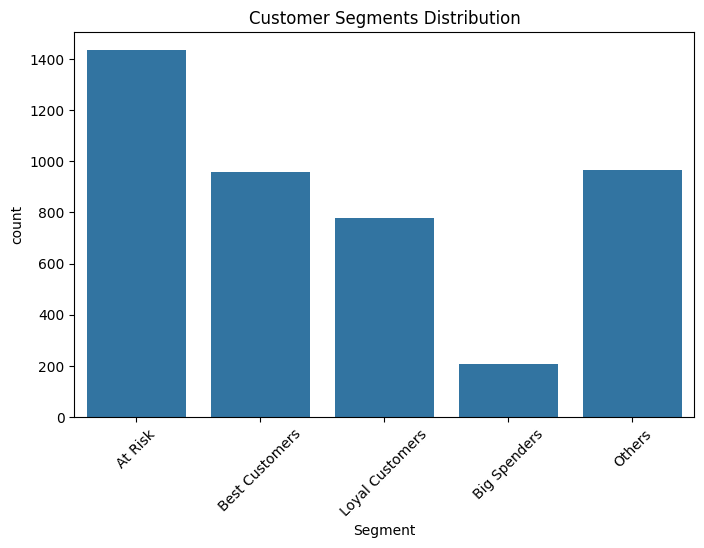

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,At Risk
12347.0,2,7,4310.00,5,5,5,555,Best Customers
12348.0,75,4,1797.24,2,4,4,244,Loyal Customers
12349.0,19,1,1757.55,4,1,4,414,Big Spenders
12350.0,310,1,334.40,1,1,2,112,At Risk


In [14]:
# ================================
# 📦 Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 📁 Load Data
# ================================
df = pd.read_csv("../data/processed/cleaned_data.csv")

# Convert to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# ================================
# 📅 Create Snapshot Date
# ================================
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# ================================
# 📊 Create RFM Table
# ================================
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# ================================
# 🔢 RFM Scoring (1–5)
# ================================
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Convert to int (IMPORTANT FIX)
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# ================================
# 🧮 Create RFM Score
# ================================
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

# ================================
# 🧠 Customer Segmentation Logic
# ================================
def segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Best Customers'
    elif row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] <= 2:
        return 'At Risk'
    elif row['M_score'] >= 4:
        return 'Big Spenders'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

# ================================
# 📊 Segment Distribution
# ================================
print(rfm['Segment'].value_counts())

# ================================
# 📈 Visualization
# ================================
plt.figure(figsize=(8,5))
sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=45)
plt.title("Customer Segments Distribution")
plt.show()

# ================================
# 💾 Save Output
# ================================
rfm.to_csv("../data/processed/rfm_data.csv")

# Preview
rfm.head()
